In [2]:
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv('LoanData.csv')
df

,Application_ID,Age,Gender,Education,Employment_Type,Income_Group,Credit_Group,Existing_Loan,Loan_Amount_Group,Loan_Status
0,LN0001,59,Male,Not Graduate,Other,Medium,Poor,Yes,Large,Rejected
1,LN0002,49,Female,Not Graduate,Salaried,Low,Fair,No,Large,Approved
2,LN0003,35,Female,Graduate,Business,Low,Good,No,Large,Rejected
3,LN0004,28,Male,Graduate,Business,Low,Good,No,Medium,Rejected
4,LN0005,41,Male,Graduate,Salaried,Low,Poor,No,Small,Approved
...,...,...,...,...,...,...,...,...,...,...
995,LN0996,28,Male,Not Graduate,Self-Employed,Low,Good,No,Large,Rejected
996,LN0997,48,Male,Graduate,Salaried,Low,Fair,No,Medium,Approved
997,LN0998,51,Male,Not Graduate,Salaried,Medium,Good,No,Medium,Approved
998,LN0999,29,Female,Graduate,Business,Low,Fair,No,Small,Rejected


In [4]:
df.shape

(1000, 10)

In [5]:
print('No of rows :',df.shape[0])
print('No of cols :',df.shape[1])

No of rows : 1000
No of cols : 10


In [6]:
df['Loan_Status'].unique()

array(['Rejected', 'Approved'], dtype=object)

In [7]:
df['Credit_Group'].unique()

array(['Poor', 'Fair', 'Good', 'Excellent'], dtype=object)

In [8]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [9]:
df['Employment_Type'].unique()

array(['Other', 'Salaried', 'Business', 'Self-Employed'], dtype=object)

In [10]:
df.describe(include='object')

,Application_ID,Gender,Education,Employment_Type,Income_Group,Credit_Group,Existing_Loan,Loan_Amount_Group,Loan_Status
count,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,2,2,4,3,4,2,3,2
top,LN0001,Male,Graduate,Salaried,Medium,Good,No,Medium,Rejected
freq,1,631,668,459,407,405,651,434,551


In [11]:
#calculate probability of ;loan approval
p_approval=(df['Loan_Status']=='Approved').mean()  #total of 0, 1 / count of o and 1
print('Probability of getting approval is :',p_approval)

Probability of getting approval is : 0.449


In [12]:
fe=df[df['Loan_Status']=='Approved']
te=df
p=len(fe)/len(te)
p

0.449

In [13]:
#probability of getting loan rejected
(df['Loan_Status']=='Rejected').mean()  #total of 0, 1 / count of o and 1

np.float64(0.551)

In [14]:
p_Rejected=1-p_approval
print(round(p_Rejected,2))

0.55


In [15]:
print(f'Chances of getting loan rejected :{round(p_Rejected*100,2)}%')

Chances of getting loan rejected :55.1%


In [16]:
df.columns

Index(['Application_ID', 'Age', 'Gender', 'Education', 'Employment_Type',
       'Income_Group', 'Credit_Group', 'Existing_Loan', 'Loan_Amount_Group',
       'Loan_Status'],
      dtype='object')

**Que :** what is the probability of approved loan that it is a male or has good credit 

**Ans :**
- As a person can be a male and can be have a goo credit at the same time, it is a Non mutual exclusive. 

In [17]:
p_m=(df['Gender'] == 'Male').mean()
p_goodcredit = (df['Credit_Group']=='Good').mean()
p_male_with_goodcredit = ((df['Credit_Group']=='Good') & (df['Gender']=='Male')).mean()
p_male_or_goodcredit = p_m + p_goodcredit - p_male_with_goodcredit
print('probability of approved loan that it is a male or has good credit :',p_male_or_goodcredit)

probability of approved loan that it is a male or has good credit : 0.784


**Que :**
What is the probability of loan approval when you are male or female ?

In [18]:
p_m=(df['Gender'] == 'Male').mean()
p_f=(df['Gender'] == 'Female').mean()
p_male_or_female=p_m+p_f
print('probability of loan approval when you are male or female :',p_male_or_female)

probability of loan approval when you are male or female : 1.0


In [19]:
df.columns

Index(['Application_ID', 'Age', 'Gender', 'Education', 'Employment_Type',
       'Income_Group', 'Credit_Group', 'Existing_Loan', 'Loan_Amount_Group',
       'Loan_Status'],
      dtype='object')

In [20]:
# what is the probability of loan approval when the applicant has good credit
dfg=df[df['Credit_Group']=='Good']
P_LApproval=(dfg['Loan_Status']=='Approved').mean()
print('probability of loan approval when the applicant has good credit',P_LApproval)

probability of loan approval when the applicant has good credit 0.5358024691358024


In [21]:
# what is the probability that a person has excellent credit score and loan got rejected.
d_ExcellentScore=(df['Credit_Group']=='Excellent').mean()
dfe=df[df['Credit_Group']=='Excellent']
p_rejected_excellent=(dfe['Loan_Status']=='Rejected').mean()
print('probability that a person has excellent credit score and loan got rejected :',round(d_ExcellentScore*p_rejected_excellent,2))

probability that a person has excellent credit score and loan got rejected : 0.05


In [22]:
# what is the probability that a person is male and loan gets approved
p_m=(df['Gender'] == 'Male').mean()
p_r=(df['Loan_Status']=='Approved').mean()
print('probability that a person is male and loan gets approved :',round(p_m*p_r,2))

probability that a person is male and loan gets approved : 0.28


In [23]:
pd.crosstab(df['Gender'],df['Loan_Status'])

Loan_Status,Approved,Rejected
Gender,,
Female,154,215
Male,295,336


#### Frequency table for Gender

In [24]:
df['Gender'].value_counts()

Gender
Male      631
Female    369
Name: count, dtype: int64

In [25]:
df['Gender'].value_counts(normalize=True)

Gender
Male      0.631
Female    0.369
Name: proportion, dtype: float64

#### Frequency table for Credit Group

In [26]:
df['Credit_Group'].value_counts()

Credit_Group
Good         405
Fair         302
Poor         157
Excellent    136
Name: count, dtype: int64

In [27]:
df['Credit_Group'].value_counts(normalize=True)

Credit_Group
Good         0.405
Fair         0.302
Poor         0.157
Excellent    0.136
Name: proportion, dtype: float64

### Frequency Table :

1. Count the records/values 

#### Two way Frequency Table

In [28]:
pd.crosstab(df['Gender'],df['Loan_Status'])

Loan_Status,Approved,Rejected
Gender,,
Female,154,215
Male,295,336


In [29]:
pd.crosstab(df['Gender'],df['Loan_Status'],normalize=True)

Loan_Status,Approved,Rejected
Gender,,
Female,0.154,0.215
Male,0.295,0.336


- Chances of getting approved for female are 15%, while for male are 29%.
- Chances of getting rejected for female are 21%, while for male are 33%.


In [30]:
df.columns

Index(['Application_ID', 'Age', 'Gender', 'Education', 'Employment_Type',
       'Income_Group', 'Credit_Group', 'Existing_Loan', 'Loan_Amount_Group',
       'Loan_Status'],
      dtype='object')

In [31]:
pd.crosstab(df['Income_Group'],df['Loan_Status'],normalize=True)

Loan_Status,Approved,Rejected
Income_Group,,
High,0.095,0.098
Low,0.163,0.237
Medium,0.191,0.216


### 2. Margins : It displays total
- pd.crosstable(x,y,margins=True)

### 3. Joint : Two events together
- pd.crosstable(x,y,margin=True)

In [32]:
# Probability that an applicant is Male AND Approved.
p_m=((df['Gender']=='Male') & (df['Loan_Status']=='Approved')).mean()
print('Probability that an applicant is Male AND Approved :',p_m)

Probability that an applicant is Male AND Approved : 0.295


In [33]:
# Probability that an applicant has good credit and Approved.
p_gca=((df['Credit_Group']=='Good') & (df['Loan_Status']=='Approved')).mean()
print('Probability that an applicant has good credit and Approved. :',p_gca)

Probability that an applicant has good credit and Approved. : 0.217


In [34]:
dfg=pd.crosstab(df['Gender'],df['Loan_Status'],margins=True)
dfg

Loan_Status,Approved,Rejected,All
Gender,,,
Female,154,215,369
Male,295,336,631
All,449,551,1000


In [35]:
dfg.reset_index()

Loan_Status,Gender,Approved,Rejected,All
0,Female,154,215,369
1,Male,295,336,631
2,All,449,551,1000


In [36]:
# Probability of female applicant to be approved
fe=154
te=369
p=fe/te
p

0.4173441734417344

### Data Distribution

In [37]:
import seaborn as sns
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [38]:
titanic=sns.load_dataset('titanic')
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


#### Data Cleaning

In [39]:
titanic.duplicated().sum()

np.int64(107)

In [40]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [41]:
titanic.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

### Explore and Understand data

In [42]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [43]:
titanic.head(4)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False


In [44]:
titanic.tail(4)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [45]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [46]:
titanic.describe(include='object')

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


#### Continuous Data Distribution

In [47]:
dfc=titanic.dropna()
dfc

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [48]:
dfc['fare'].describe()
dfc

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


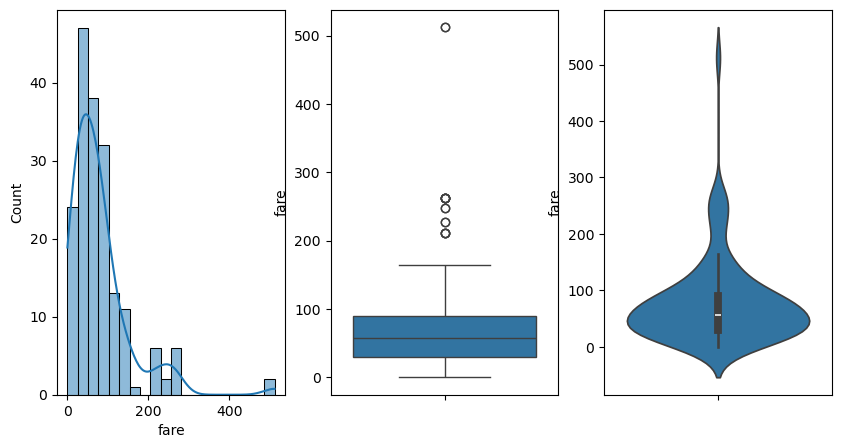

In [49]:
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,3,figsize=(10,5))
sns.histplot(x=dfc['fare'],ax=axes[0],kde=True,bins=20)
sns.boxplot(dfc['fare'],ax=axes[1])
sns.violinplot(dfc['fare'],ax=axes[2])

plt.show()

In [50]:
dfc.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [51]:
print('Mean Age :',dfc['age'].mean())
print('Median Age :',dfc['age'].median())
print('Mode Age :',dfc['age'].mode())
print('Standard Deviation Age :',dfc['age'].std())
print('Min Age :',dfc['age'].min())
print('Max Age :',dfc['age'].max())

Mean Age : 35.62318681318681
Median Age : 36.0
Mode Age : 0    36.0
Name: age, dtype: float64
Standard Deviation Age : 15.6716153573797
Min Age : 0.92
Max Age : 80.0


import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x=dfc['age'].values)
plt.show()


### Discrete Data Dritribution

In [53]:
dfc.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

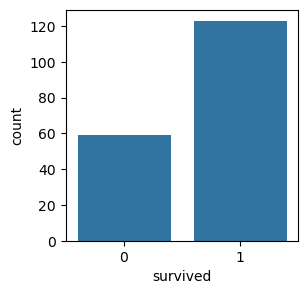

In [54]:
plt.figure(figsize=(3,3))
sns.countplot(x=dfc['survived'])
plt.show()

In [55]:
dfc['pclass'].unique()

array([1, 3, 2])

In [56]:
dfc['pclass'].value_counts()

pclass
1    157
2     15
3     10
Name: count, dtype: int64

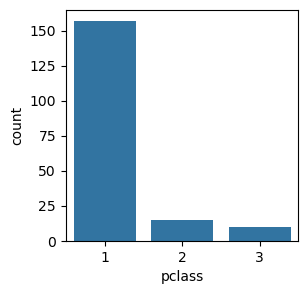

In [57]:
plt.figure(figsize=(3,3))
sns.countplot(x=dfc['pclass'])
plt.show()

In [ ]:
# display the survival by pclass
dfc.groupby(dfc[''])

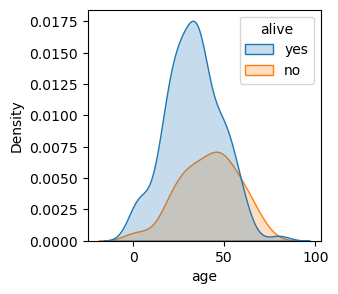

In [63]:
# display the age distribution by survival
plt.figure(figsize=(3,3))
sns.kdeplot(x=dfc['age'],hue=dfc['alive'],fill=True)
plt.show()

> We observe 

In [65]:
dfc['pclass']=dfc['pclass'].map({1:'Lower',2:'Middle',3:'Higher'})

C:\Users\Odugu Vamsi\AppData\Local\Temp\ipykernel_4844\2246286652.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfc['pclass']=dfc['pclass'].map({1:'Lower',2:'Middle',3:'Higher'})


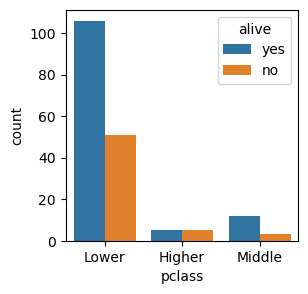

In [69]:
plt.figure(figsize=(3,3))
sns.countplot(x=dfc['pclass'],hue=dfc['alive'],fill=True)
plt.show()

In [71]:
pd.crosstab(dfc['pclass'],dfc['alive'],margins=True)

alive,no,yes,All
pclass,,,
Higher,5,5,10
Lower,51,106,157
Middle,3,12,15
All,59,123,182


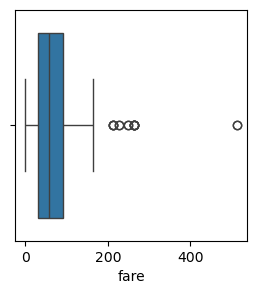

In [73]:
plt.figure(figsize=(3,3))
sns.boxplot(x=dfc['fare'])
plt.show()

> There were outliers in fares, some people have high fares

### Probability Distribution
**1. Discrete :**
   1. Bernouli : 1 trail --> two possible outcomes.
   2. Bimomial : Multiple trails --> two possible outcomes.
   3. Poisson : Fix time.  Ex : How many members are visit a website in next 1 hour ?
      
**2. Continuous :**
   1. uniform : Every range has equal chance.
   2. Normal : Middle range has more channces.
   3. log : Incresing / Decresing
   4. Exponential : Incresing / Decresing
   5. Pareto : 80:20 rule ; (20% of reasons for 80% of outcome).

### Probability Distribution Functions :
1. Discrete - pmf() --> p(x==2) **Probability mass function**
2. Continuous - pdf() --> p(1<x<5) **Probability density function**
3. cdf() --> Both probability; When <, >:P(x<2), P(x<=10) **Cumulative density function**

#### Scipy mode:
- from scipy import stats

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

In [3]:
# what is the propbablity of getting head when we toss a coin 3 times
df=pd.DataFrame({'x':[0,1,2,3],'Outcome':[['TTT'],['TTH','HTT','THT'],['HHT','THH','HTH'],['HHH']]})
df

,x,Outcome
0,0,[TTT]
1,1,"[TTH, HTT, THT]"
2,2,"[HHT, THH, HTH]"
3,3,[HHH]


In [9]:
df['Outcome_Num']=df['Outcome'].apply(lambda x:len(x))

In [7]:
df['Probability']=df['Outcome'].apply(lambda x:len(x))/8

In [10]:
df

,x,Outcome,Probability,Outcome_Num
0,0,[TTT],0.125,1
1,1,"[TTH, HTT, THT]",0.375,3
2,2,"[HHT, THH, HTH]",0.375,3
3,3,[HHH],0.125,1


- probability of getting 0 head
P(X=0) = 1.25
- Probability of getting 2 heads
P(x==2) = 0.376

### 1. Bernoulli Distribution (bernoulli)


**Probability of getting a head when we toss a coin once**


In [26]:
# create a data

k=1 #no. of trails
p=0.5 #probability
data=stats.bernoulli.rvs(0.5,size=10) #creating random data
display(data)

from scipy.stats import bernoulli

prob=bernoulli.pmf(k=1,p=p) #Cal probability of getting a head 
print('probability of getting a head :',prob)

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0])

probability of getting a head : 0.5


### 2. Binomial Distribution (binom)

In [21]:
from scipy.stats import binom

**What is the probability of getting exactly 2 heads in 10 trails**

In [27]:
x=2
n=10
p=0.5
data=binom.rvs(n,p,size=10)
print(data)

prob_2h=binom.pmf(x,n,p)
print('Probability of getting exactly 2 heads in 10 trails :',round(prob_2h,3))

[7 4 4 6 5 7 5 4 7 3]
Probability of getting exactly 2 heads in 10 trails : 0.044


**What is the probability of getting exactly 5 heads in 12 trails**

In [32]:
x=5
n=12
p=0.5
data=binom.rvs(n,p,size=10)
print(data)

prob_5h=binom.pmf(x,n,p)
print('Probability of getting exactly 5 heads in 12 trails :',round(prob_5h,2))

[ 7  7  4 11  7  6  4  7  7  4]
Probability of getting exactly 5 heads in 12 trails : 0.19


### 3. Poisson Distribution

**Average rate of people visiting a cafe is 15%, then what is the probability of 30 people visiting cafe in next 1 hour**

In [36]:
from scipy.stats import poisson

lam = 5
mean = 30
prob_30 = poisson.pmf(mean,lam)
prob_30

np.float64(2.3657434461796272e-14)